In [1]:
import pandas as pd

data = pd.read_csv("U4_01_housing.csv")

In [2]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
data["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [4]:
# Cek jumlah baris, ada nilai kosong (NaN), tipe data
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [5]:
# statisktik dasar (mean, min, max)
data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

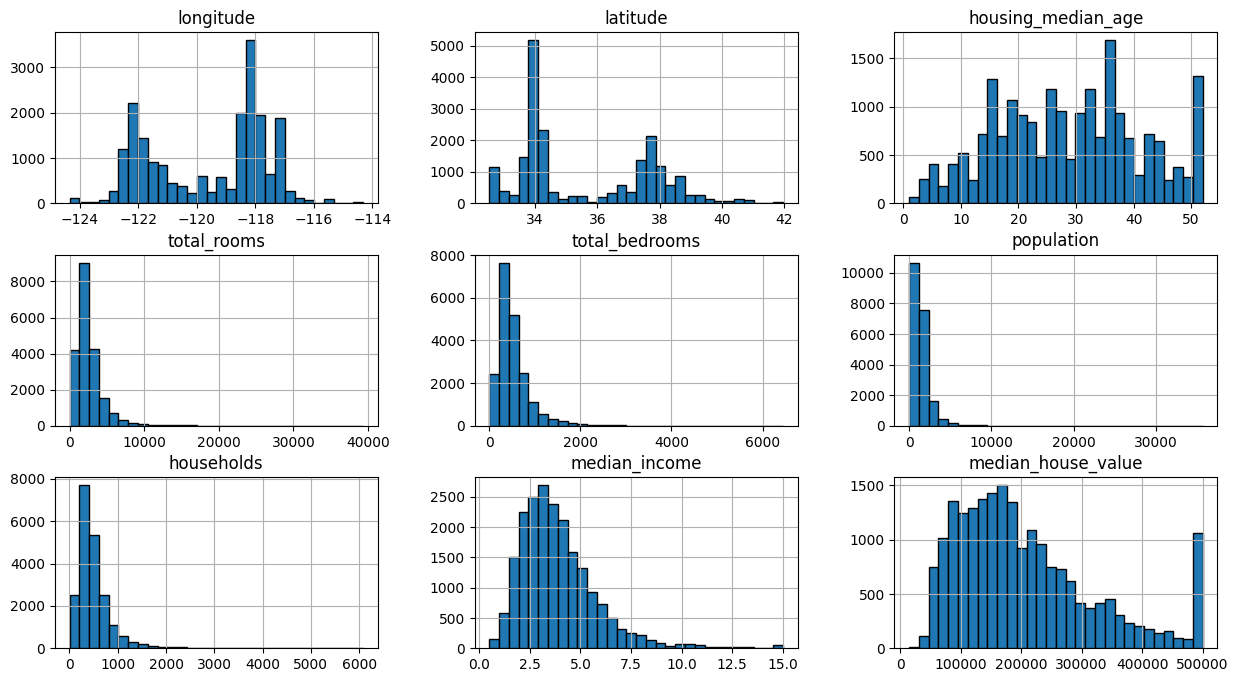

In [6]:
# Visualisasi data
data.hist(figsize=(15,8), bins=30, edgecolor="black")

<Axes: xlabel='longitude', ylabel='latitude'>

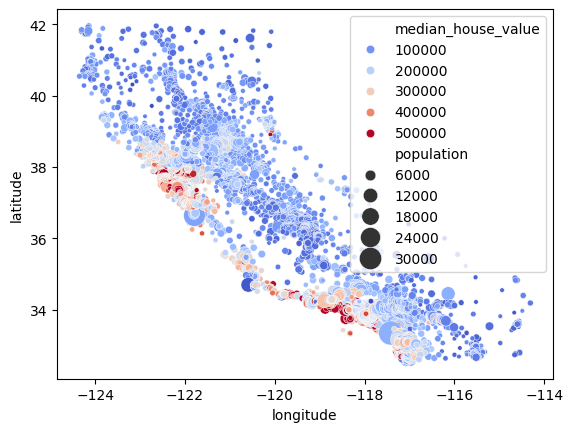

In [7]:
# Visualisasi Data
# Lihat Distribusi Data (apakah normal, miring, dll)
import seaborn as sb
sb.scatterplot(x="longitude", y="latitude", data=data, hue="median_house_value", palette="coolwarm",
               size="population", sizes=(10, 300))

# import matplotlib.pyplot as plt

# plt.scatter(
#     datos["latitude"],
#     datos["longitude"],
#     c=datos["median_house_value"],
#     s=datos["population"] / 100,
#     cmap="coolwarm"
# )
# plt.show()

<Axes: xlabel='longitude', ylabel='latitude'>

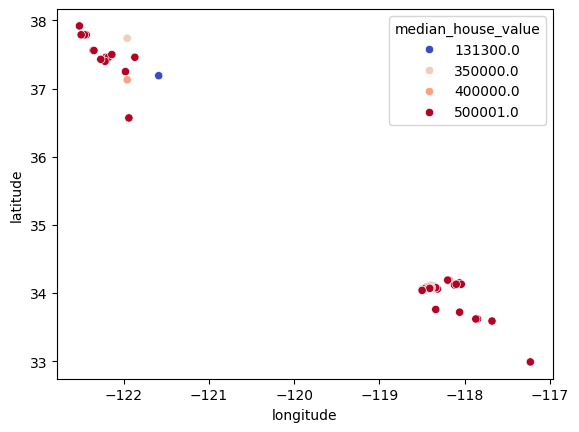

In [8]:
sb.scatterplot(x="longitude", y="latitude", data=data[(data.median_income > 14)], hue="median_house_value", palette="coolwarm")

In [9]:
# Menghapus data kosong (NaN)
data_na = data.dropna()

In [10]:
data_na.info()

<class 'pandas.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [11]:
# Category Menjadi Numerik
data_na["ocean_proximity"]

data_na["ocean_proximity"].value_counts()
# 1, 2, 3, 4, 5

# Dumies / One Hot Encoding (*Ini Lebih baik)
# NEAR BAY  INLAND  NEAR OCEAN
#     1       0         0
#     0       0         1
dummies = pd.get_dummies(data_na["ocean_proximity"], dtype=int)

In [12]:
data_na = data_na.join(dummies)

In [13]:
data_na.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,0,0,0,1,0


In [14]:
data_na = data_na.drop(["ocean_proximity"], axis = 1)

In [15]:
data_na.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,0,1,0


<Axes: >

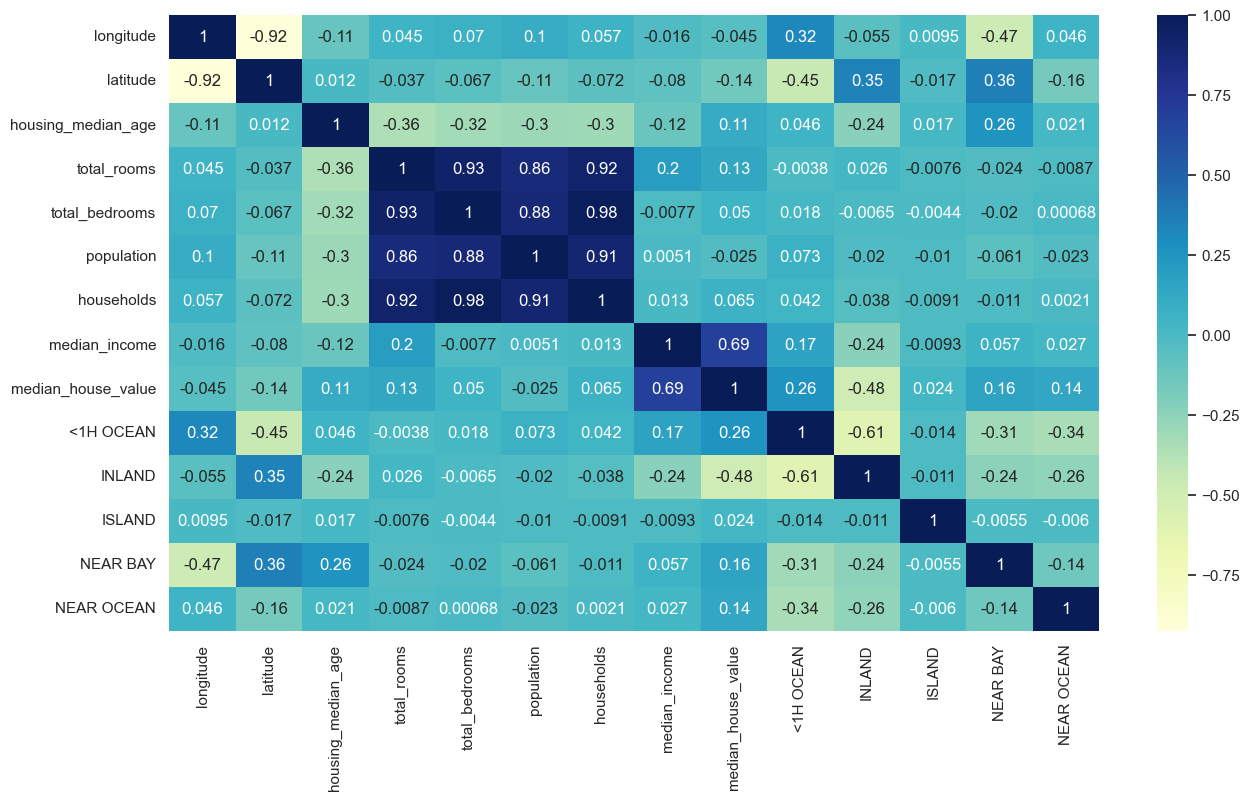

In [16]:
# Analisis  Korelasi
sb.set(rc={'figure.figsize':(15,8)})
sb.heatmap(data_na.corr(), annot = True, cmap="YlGnBu")

In [17]:
data_na.corr()["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688355
<1H OCEAN             0.257614
NEAR BAY              0.160526
NEAR OCEAN            0.140378
total_rooms           0.133294
housing_median_age    0.106432
households            0.064894
total_bedrooms        0.049686
ISLAND                0.023525
population           -0.025300
longitude            -0.045398
latitude             -0.144638
INLAND               -0.484787
Name: median_house_value, dtype: float64

<Axes: xlabel='median_house_value', ylabel='median_income'>

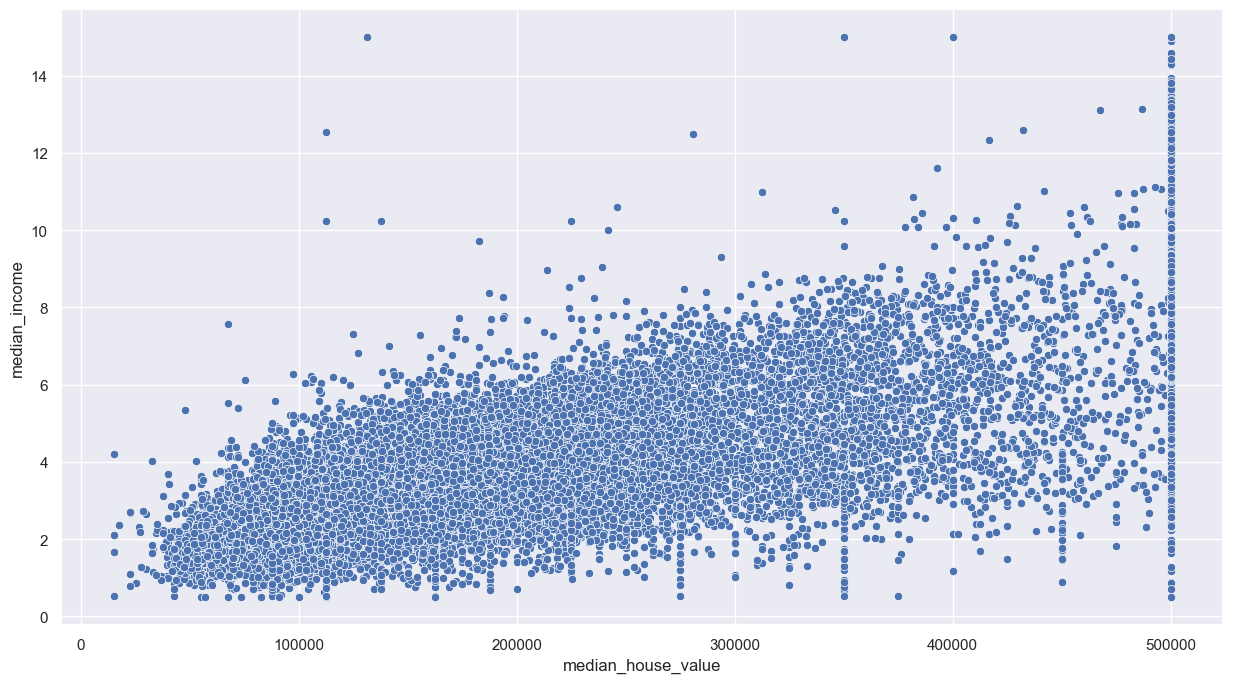

In [18]:
sb.scatterplot(x=data_na["median_house_value"], y=data_na["median_income"])

In [19]:
data_na["bedroom_ratio"] = data_na["total_bedrooms"] / data_na["total_rooms"]

<Axes: >

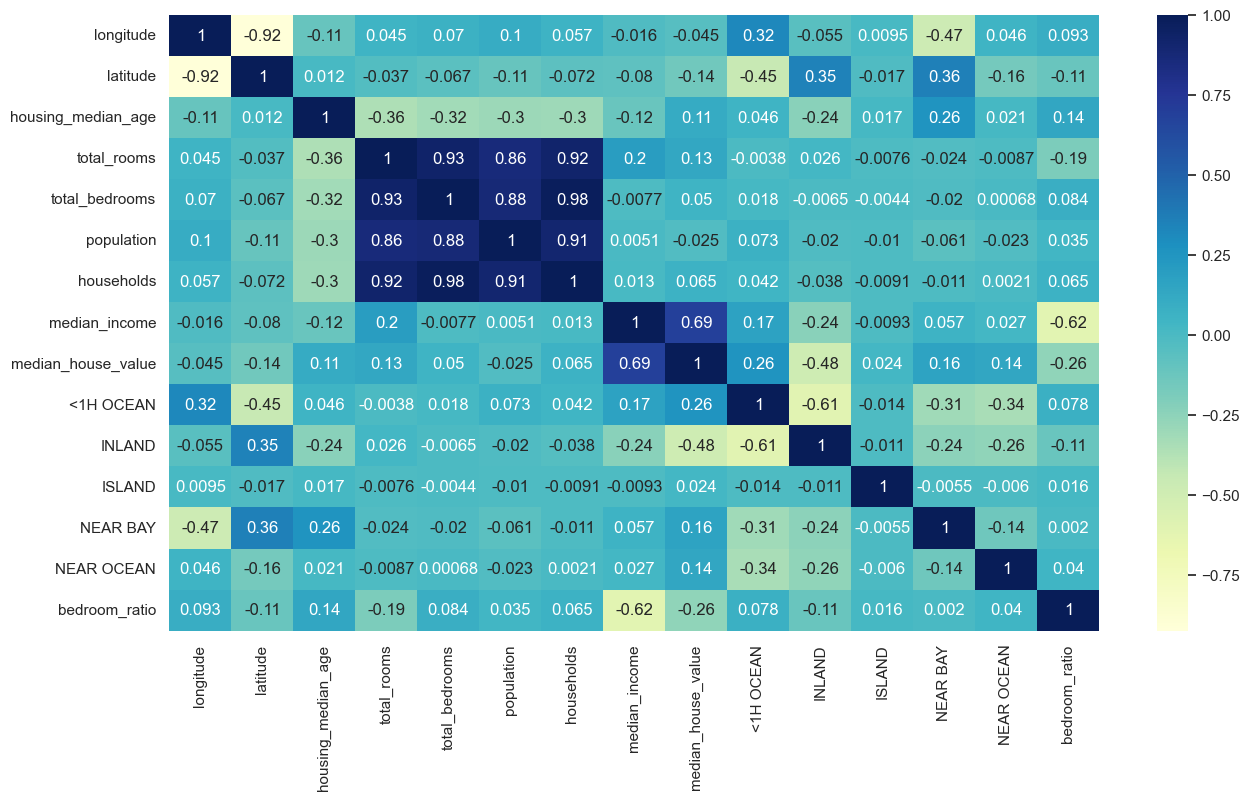

In [20]:
sb.set(rc={'figure.figsize':(15,8)})
sb.heatmap(data_na.corr(), annot = True, cmap="YlGnBu")

In [21]:
# Pisah Fitur Label
X = data_na.drop(["median_house_value"], axis=1)
y = data_na["median_house_value"]

In [22]:
# Pisahkan data menjadi 2 bagian: set data pelatihan dan set data pengujian.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
X_train.shape

(16346, 14)

In [24]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
prediksi = model.predict(X_test)

In [26]:
comparativa = {"Prediksi": prediksi, "Valor Real": y_test}
pd.DataFrame(comparativa)

,Prediksi,Valor Real
14416,213991.680077,245800.0
16383,149282.857580,137900.0
7731,203177.499908,218200.0
1410,177851.665245,220800.0
1335,202575.591446,170500.0
...,...,...
8291,276492.961615,500001.0
6274,179216.420782,157900.0
2997,106908.540256,100200.0
13440,133601.442018,127700.0


In [27]:
# Overfitting sobreajuste
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

0.6516417271383903
0.6530218415630724


In [28]:
# Error
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(y_test, prediksi)
mse

4744989045.435231

In [29]:
rmse = np.sqrt(mse)
rmse #Angka kita salah menghitung

np.float64(68883.88088250568)

In [30]:
# Scaler Esxcalmiento
data_na.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,bedroom_ratio
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,-119.570689,35.633221,28.633094,2636.504233,537.870553,1424.946949,499.433465,3.871162,206864.413155,0.442128,0.317917,0.000245,0.111095,0.128615,0.213039
std,2.003578,2.136348,12.591805,2185.269567,421.385070,1133.208490,382.299226,1.899291,115435.667099,0.496652,0.465678,0.015641,0.314257,0.334782,0.057983
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.100000
25%,-121.800000,33.930000,18.000000,1450.000000,296.000000,787.000000,280.000000,2.563700,119500.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.175427
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.536500,179700.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.203162
75%,-118.010000,37.720000,37.000000,3143.000000,647.000000,1722.000000,604.000000,4.744000,264700.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.239821
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_esc = scaler.fit_transform(X_train)
X_test_esc = scaler.fit_transform(X_test)

In [32]:
X_train

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,bedroom_ratio
17727,-121.80,37.32,14.0,4412.0,924.0,2698.0,891.0,4.7027,1,0,0,0,0,0.209429
2057,-119.63,36.64,33.0,1036.0,181.0,620.0,174.0,3.4107,0,1,0,0,0,0.174710
6453,-118.06,34.12,25.0,3891.0,848.0,1848.0,759.0,3.6639,0,1,0,0,0,0.217939
4619,-118.31,34.07,28.0,2362.0,949.0,2759.0,894.0,2.2364,1,0,0,0,0,0.401778
15266,-117.27,33.04,27.0,1839.0,392.0,1302.0,404.0,3.5500,0,0,0,0,1,0.213159
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11397,-117.97,33.72,24.0,2991.0,500.0,1437.0,453.0,5.4286,1,0,0,0,0,0.167168
12081,-117.54,33.76,5.0,5846.0,1035.0,3258.0,1001.0,4.7965,1,0,0,0,0,0.177044
5447,-118.42,34.01,42.0,1594.0,369.0,952.0,362.0,3.0990,1,0,0,0,0,0.231493
866,-122.04,37.57,12.0,5719.0,1064.0,3436.0,1057.0,5.2879,0,0,0,1,0,0.186047


In [33]:
pd.DataFrame(X_train_esc)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,-1.106514,0.786208,-1.162062,0.829311,0.929297,1.131110,1.040744,0.438412,1.122740,-0.678799,-0.013549,-0.356370,-0.385407,-0.064010
1,-0.024671,0.467873,0.348657,-0.738558,-0.850523,-0.708899,-0.856152,-0.242389,-0.890678,1.473189,-0.013549,-0.356370,-0.385407,-0.664804
2,0.758045,-0.711838,-0.287435,0.587350,0.747242,0.378459,0.691525,-0.108969,-0.890678,1.473189,-0.013549,-0.356370,-0.385407,0.083253
3,0.633408,-0.735245,-0.048901,-0.122742,0.989183,1.185124,1.048681,-0.861168,1.122740,-0.678799,-0.013549,-0.356370,-0.385407,3.264551
4,1.151895,-1.217429,-0.128412,-0.365632,-0.345083,-0.105008,-0.247664,-0.168986,-0.890678,-0.678799,-0.013549,-0.356370,2.594660,0.000545
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16341,0.802914,-0.899094,-0.366947,0.169376,-0.086375,0.014531,-0.118029,0.820914,1.122740,-0.678799,-0.013549,-0.356370,-0.385407,-0.795321
16342,1.017288,-0.880369,-1.877666,1.495284,1.195192,1.626974,1.331760,0.487838,1.122740,-0.678799,-0.013549,-0.356370,-0.385407,-0.624420
16343,0.578568,-0.763334,1.064261,-0.479414,-0.400179,-0.414923,-0.358779,-0.406634,1.122740,-0.678799,-0.013549,-0.356370,-0.385407,0.317807
16344,-1.226165,0.903243,-1.321086,1.436303,1.264660,1.784588,1.479914,0.746774,-0.890678,-0.678799,-0.013549,2.806074,-0.385407,-0.468636


In [34]:
data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000
